# description

# initial settings, packages

In [ ]:
# use conda environment celldive00
print('november')

november


In [ ]:
# import packages
from tifffile import TiffFile
from tifffile import imread
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.transform import rescale
from tqdm import tqdm  
import pandas as pd
import time
import cupy as cp
import pickle
import types
import os
from concurrent.futures import ThreadPoolExecutor  
import math

from cupyx.scipy.signal import fftconvolve


In [ ]:
# functions

def downscale_image(image,scalefactor=100):
    return cv2.resize(image, (image.shape[1] // scalefactor, image.shape[0] // scalefactor), interpolation=cv2.INTER_LINEAR)

def downscale_image_rgb(image, new_size=None, scalefactor=100):
    """
    Resizes a 3D image array (e.g., height x width x channels).
    
    Parameters:
    - image: 3D numpy array (height x width x channels)
    - new_size: tuple (new_width, new_height) to resize the image to (optional)
    - scalefactor: float by which to scale the image (optional)
    
    Returns:
    - Resized 3D numpy array
    """
    
    # If a scalefactor is given, calculate the new size based on it
    if scalefactor:
        new_width = int(image.shape[1] // scalefactor)
        new_height = int(image.shape[0] // scalefactor)
        new_size = (new_width, new_height)
    
    # If new_size is provided, use that
    if new_size:
        # Perform the resizing using OpenCV
        resized_image = cv2.resize(image, new_size, interpolation=cv2.INTER_LINEAR)
    else:
        # If no new_size or scalefactor is provided, return the original image
        resized_image = image
    
    return resized_image

def downscale_image_gpu(image,scalefactor=100): # haven't tested if this works
    h, w = image.shape
    return cp.array(image[:h//scalefactor * scalefactor, :w//scalefactor * scalefactor].reshape(h//scalefactor, scalefactor, w//scalefactor, scalefactor).mean(axis=(1, 3))) 

In [ ]:
raw_data_directory = '../raw_data/' # filesep at end


# choose dapi file

In [ ]:

# get dapi filenames
filenames = os.listdir(raw_data_directory)
filenames_dapi = [x for x in filenames if x.endswith('.tif') and 'dapi' in x.lower()]

# sort dapi filenames
number_codes = [x.split('_')[1] for x in filenames_dapi]
number_codes_converted = [ 1000000*float(x.split('.')[0]) + 1000*float(x.split('.')[1]) + float(x.split('.')[2]) for x in number_codes]

combined = list(zip(filenames_dapi,number_codes_converted))
combined_sorted = sorted(combined, key=lambda x: x[1])

filenames_dapi_sorted,number_codes_converted_sorted = zip(*combined_sorted)

filenames_dapi_sorted

('SLIDE-0265_0.0.2_R000_DAPI_F.tif',
 'SLIDE-0265_0.0.2_R000_DAPI_F_Tiled.tif',
 'SLIDE-0265_1.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_2.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_2.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_3.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_3.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_4.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_4.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_5.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_5.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_6.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_6.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_7.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_7.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_8.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_8.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_9.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_9.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_10.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_10.0.4_R000_DAPI__FINAL_F.ome.tif'

In [ ]:
# remove variables
del combined, combined_sorted,filenames,filenames_dapi, number_codes, number_codes_converted,number_codes_converted_sorted

## display dapi images

In [ ]:
for filename in tqdm(filenames_dapi_sorted):
    # load tif file
    with TiffFile(raw_data_directory+filename) as tif:
        image = tif.asarray()

    


100%|██████████| 2/2 [01:51<00:00, 55.63s/it]


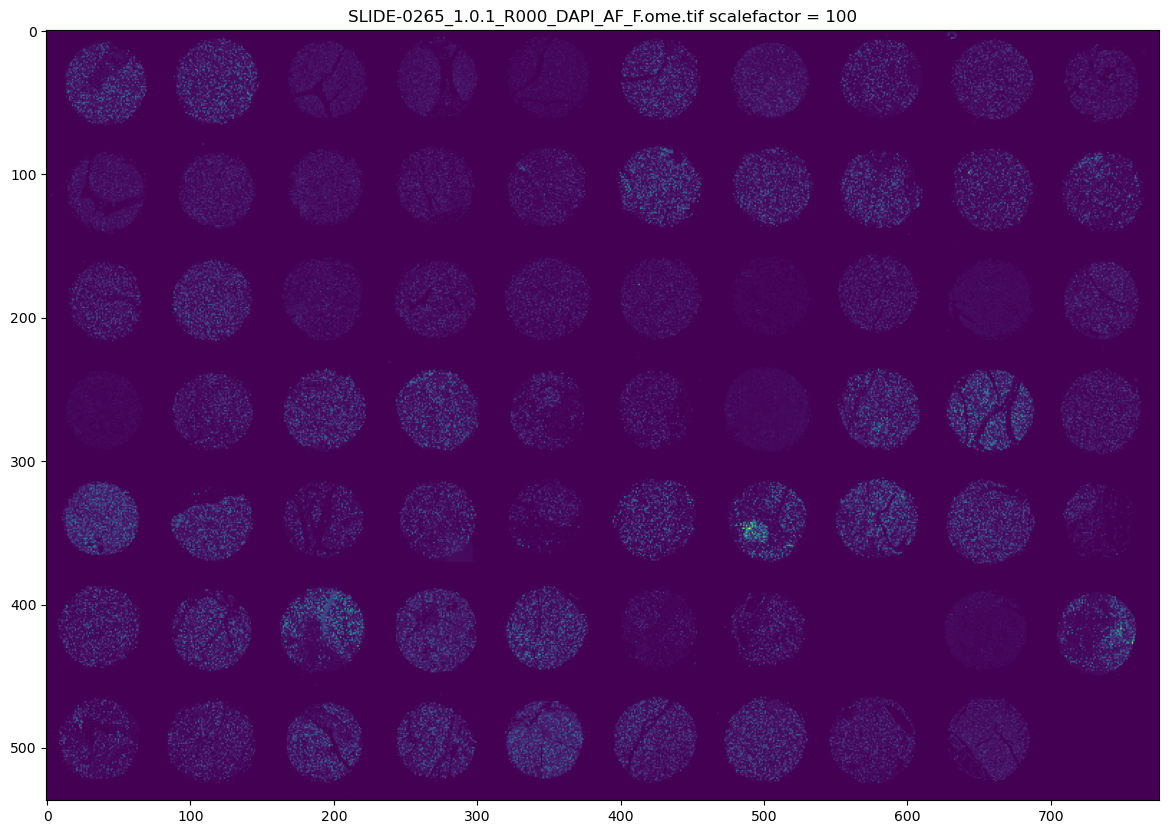

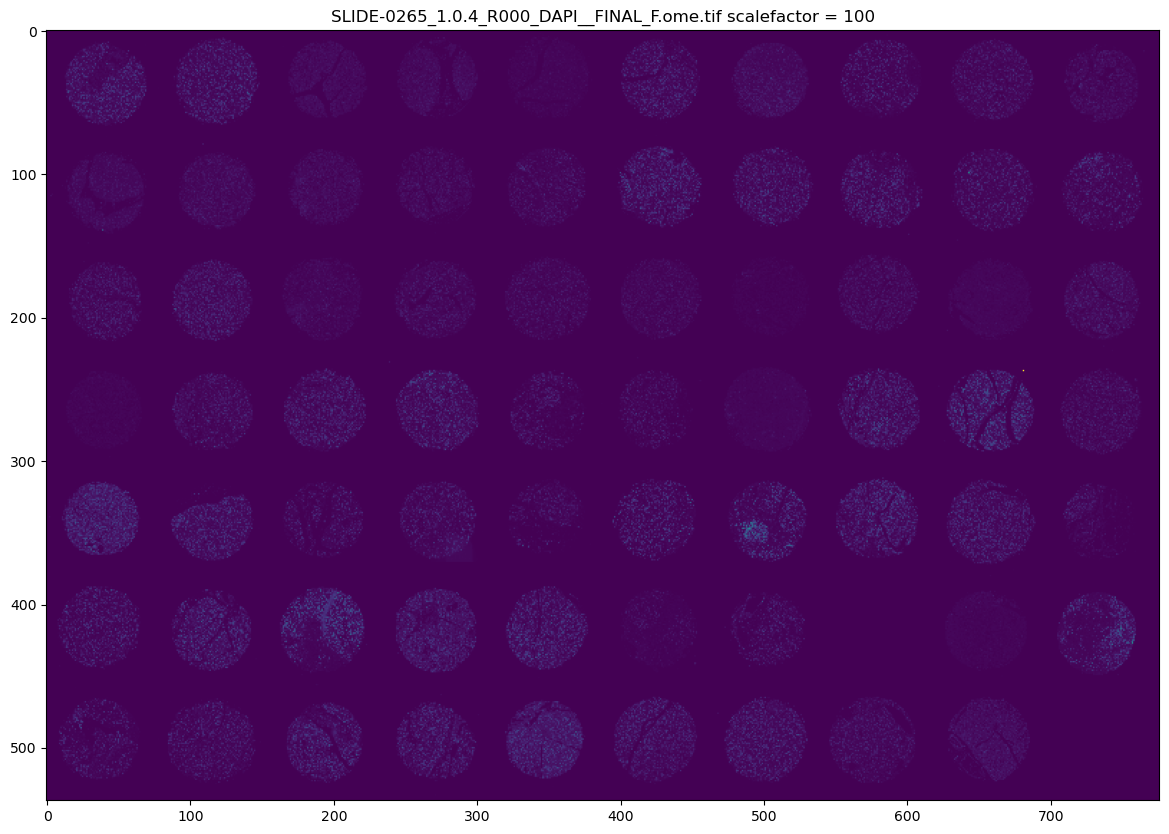

In [ ]:
# for counter in tqdm(range(len(filenames_dapi_sorted))):
for counter in tqdm(range(2,4)):
    filename = filenames_dapi_sorted[counter]
    
    # load tif file
    image = imread(raw_data_directory + filename)
        
    # display image
    _,ax = plt.subplots(figsize = (20,10))
    ax.imshow(downscale_image(image,scalefactor=100))
    ax.set_title(f"{filename} scalefactor = 100")

del counter, filename, image, ax

In [ ]:
filenames_dapi_sorted[2]

'SLIDE-0265_1.0.1_R000_DAPI_AF_F.ome.tif'

In [ ]:
filenames_dapi_sorted[3]

'SLIDE-0265_1.0.4_R000_DAPI__FINAL_F.ome.tif'

In [ ]:
# remove variables
del filenames_dapi_sorted

# load dapi image of choice, then display it

In [ ]:
filename = 'SLIDE-0265_1.0.1_R000_DAPI_AF_F.ome.tif'
image = imread(raw_data_directory+filename)

del filename

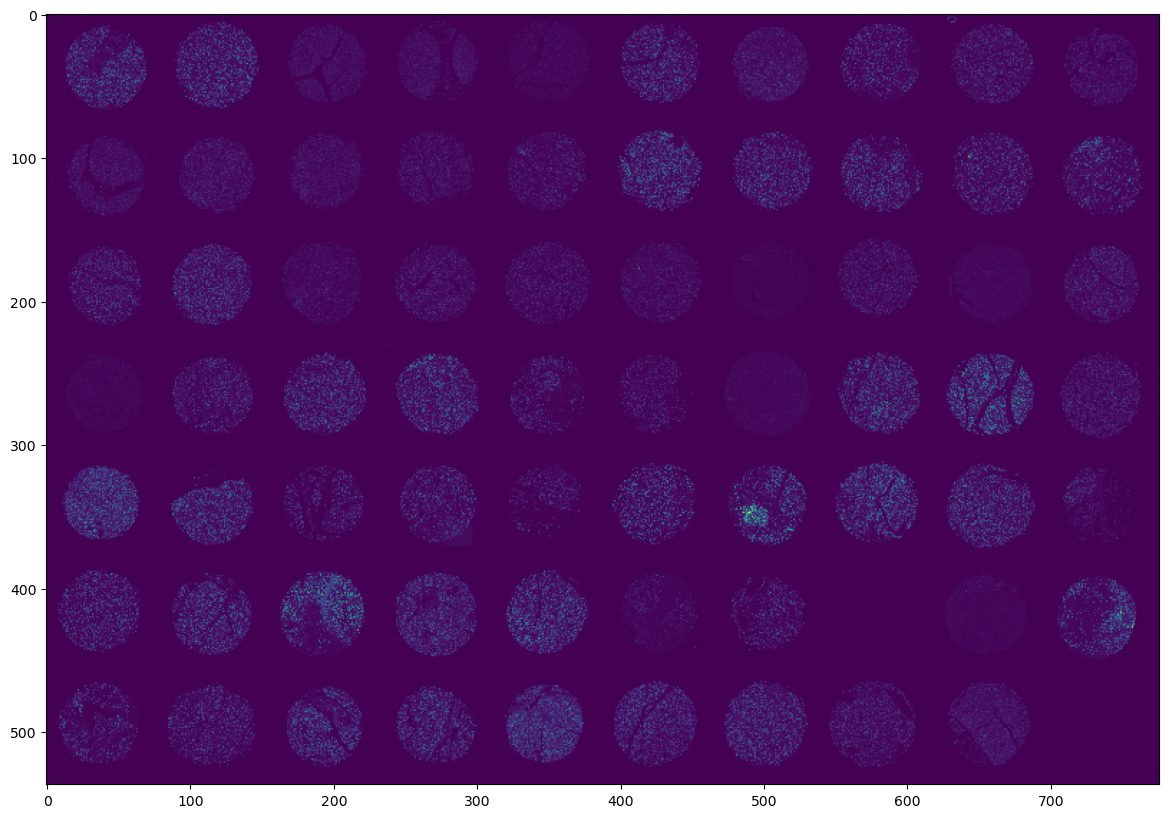

In [ ]:
_, ax = plt.subplots(figsize=(20,10))
ax.imshow(downscale_image(image,scalefactor=100)); del ax

# determine diameter of cores, in pixels

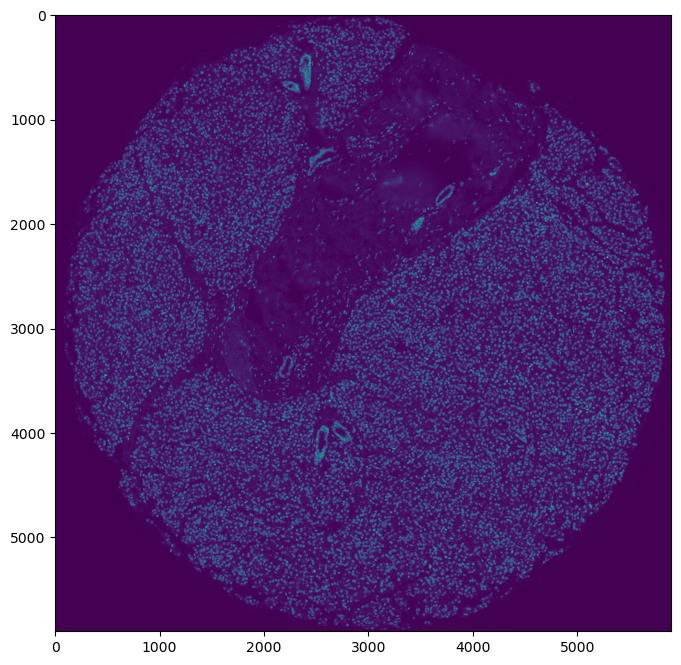

In [ ]:
diameter = 5_900

r0 = 780
r1 = r0 + diameter
c0 = 1180
c1 = c0 + diameter

_, ax = plt.subplots(figsize = (8,8))
ax.imshow(image[r0:r1,c0:c1]) # takes ~5-6 sec

del ax,r0,r1,c0,c1

# detect circles

In [ ]:
# 

scalefactor = 200

image_downscaled = downscale_image(image,scalefactor=scalefactor)
radius_downscaled = int(diameter/2/scalefactor)

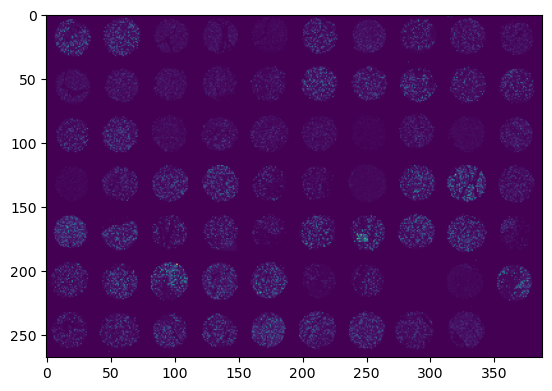

In [ ]:
plt.imshow(image_downscaled)

In [ ]:
from cupyx.scipy.signal import fftconvolve
from skimage.morphology import disk

I_gpu = cp.asarray(image_downscaled, dtype=cp.float32)
K = disk(radius_downscaled).astype(np.float32)
K /= K.sum()
K_gpu = cp.asarray(K)

out_gpu = fftconvolve(I_gpu, K_gpu, mode='same')
out_image_downscaled = cp.asnumpy(out_gpu)  # if you need it back on CPU

del I_gpu,K,K_gpu,out_gpu


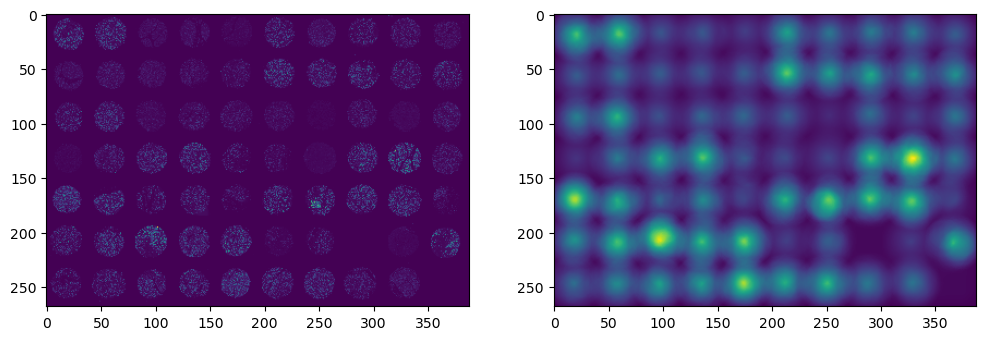

In [ ]:
_,ax_grid = plt.subplots(1,2,figsize=(12,6))
ax = ax_grid[0];  ax.imshow(image_downscaled)
ax = ax_grid[1];  ax.imshow(out_image_downscaled)

del ax_grid, ax

(68, 2)


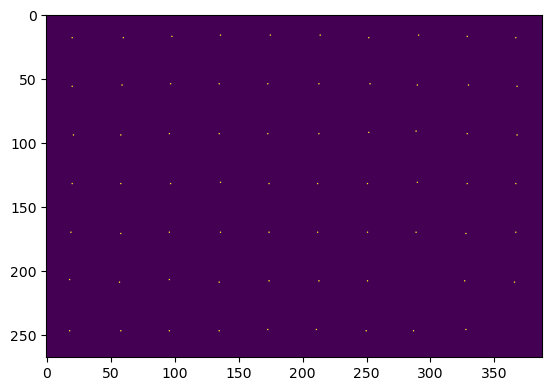

In [ ]:
from skimage.feature import peak_local_max

# I: 2D image, float32 or uint16
coordinates_downscaled = peak_local_max(
    out_image_downscaled,
    min_distance=10,      # minimum pixels between peaks
    threshold_abs=0.2,    # intensity threshold
    exclude_border=True   # ignore edges
)

coordinates_image_downscaled = np.zeros_like(out_image_downscaled)
for item in coordinates_downscaled:
    coordinates_image_downscaled[item[0],item[1]] = 1
del item

print(coordinates_downscaled.shape)  # (N_peaks, 2)
plt.imshow(coordinates_image_downscaled)




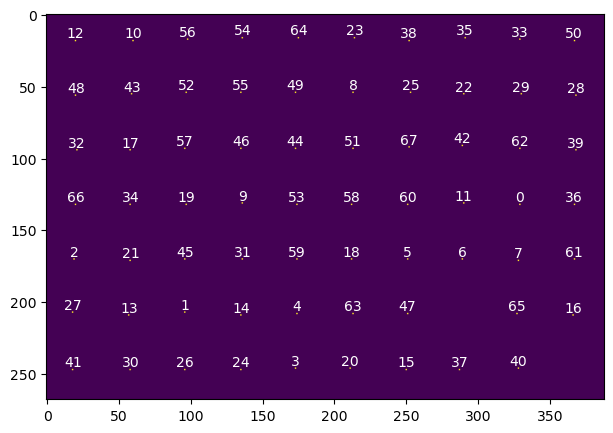

In [ ]:
_,ax = plt.subplots(figsize = (10,5))
ax.imshow(coordinates_image_downscaled)
for counter,item in enumerate(coordinates_downscaled):
    ax.text(item[1],item[0],f"{counter}",c = [1,1,1],ha = 'center',va = 'bottom')
    


In [ ]:
# define df_components

# set constants
coordinates = (coordinates_downscaled*scalefactor).astype(int)
radius = int(diameter/2)
rim = 200

# define 
mylist = []
for item in coordinates:
    entry0 = item[1] - radius - rim # column 0
    entry1 = item[0] - radius - rim # row 0
    entry2 = radius + radius + rim + rim # col width
    entry3 = radius + + radius + rim + rim # row width
    mylist.append([entry0,entry1,entry2,entry3])
    
    del entry0,entry1,entry2, entry3
    
mydict = {'bounding_box':mylist}
df_components = pd.DataFrame(mydict)

del mylist,mydict, item


In [ ]:
df_components

,bounding_box
0,"[62650, 23250, 6300, 6300]"
1,"[16050, 38250, 6300, 6300]"
2,"[650, 30850, 6300, 6300]"
3,"[31450, 46050, 6300, 6300]"
4,"[31650, 38450, 6300, 6300]"
...,...
63,"[39450, 38450, 6300, 6300]"
64,"[31850, 50, 6300, 6300]"
65,"[62250, 38450, 6300, 6300]"
66,"[850, 23250, 6300, 6300]"


0it [00:00, ?it/s]

68it [00:04, 16.62it/s]
68it [00:00, 5297.90it/s]


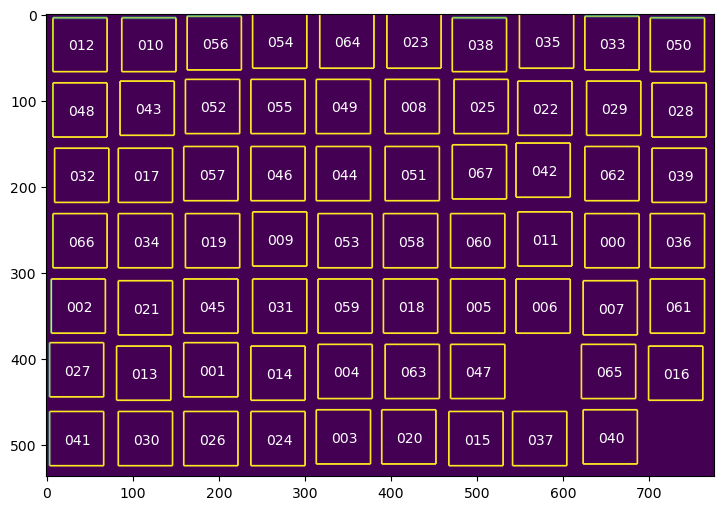

In [ ]:
# plot the box's locations

myscalefactor = 100
mywidth = 100

# create downscaled image of boxes
boxes = np.zeros((image.shape[0],image.shape[1]))
for index, row in tqdm(df_components.iterrows()):
    # add boundaries
    [x,y,w,h] = row['bounding_box']
    boxes[y-mywidth:y+mywidth,x:x+w] = 1
    boxes[y+h-mywidth:y+h+mywidth,x:x+w] = 1
    boxes[y:y+h,x-mywidth:x+mywidth] = 1
    boxes[y:y+h,(x+w-mywidth):(x+w+mywidth)] = 1
    
    # # set the 'box_number', add text to image
    # str_to_insert = f"_box{index:03}"
    # ax.text(y,x,str_to_insert)

boxes_downscaled = downscale_image(boxes,scalefactor=myscalefactor)

_,ax = plt.subplots(figsize=(12,6))
ax.imshow(boxes_downscaled)

for index, row in tqdm(df_components.iterrows()):
    # get box boundaries
    [x,y,w,h] = row['bounding_box']
    
    # set text coordinates
    text_coord_1 = round((x+0.5*w)/myscalefactor)
    text_coord_2 = round((y+0.5*h)/myscalefactor)
    
    # set the 'box_number', add text to image
    str_to_insert = f"{index:03}"
    ax.text(text_coord_1,text_coord_2,str_to_insert,ha='center',va='center',color='white')

del myscalefactor,mywidth,boxes,index,row,x,y,w,h
del ax, text_coord_1,text_coord_2, str_to_insert
del boxes_downscaled

In [ ]:
# reorder box locations based on user defined locations in 'mylist'

mylist = [12, 10 , 56, 54 , 64, 23 , 38, 35, 33, 50, 
          48, 43, 52, 55, 49,   8  , 25, 22, 29, 28,
          32, 17, 57, 46, 44, 51, 67, 42, 62, 39,
          66, 34, 19, 9, 53, 58, 60, 11, 0, 36,
          2, 21, 45, 31, 59, 18, 5, 6, 7, 61,
          27, 13, 1, 14, 4, 63, 47, 65, 16,
          41, 30, 26, 24, 3, 20, 15, 37, 40]

if len(mylist) == len(set(mylist)):
    print('no repeats detected in mylist')
else:
    print('UH OH, repeat detected in mylist')
    
if len(np.unique(np.diff(np.sort(mylist)))) == 1:
    print('no gaps detected in mylist')
else:
    print('UH OH, gaps detected in mylist')
    
mydict = {item:counter for counter,item in enumerate(mylist)}

df_components['original_index'] = df_components.index
df_components['pseudo_order'] = df_components.index.map(mydict)
df_components = df_components.sort_values(by = 'pseudo_order', ascending = True)
df_components = df_components.reset_index(drop=True)

# del mylist, mydict

df_components

no repeats detected in mylist
no gaps detected in mylist


,bounding_box,original_index,pseudo_order
0,"[850, 450, 6300, 6300]",12,0
1,"[8850, 450, 6300, 6300]",10,1
2,"[16450, 250, 6300, 6300]",56,2
3,"[24050, 50, 6300, 6300]",54,3
4,"[31850, 50, 6300, 6300]",64,4
...,...,...,...
63,"[31450, 46050, 6300, 6300]",3,63
64,"[39050, 46050, 6300, 6300]",20,64
65,"[46850, 46250, 6300, 6300]",15,65
66,"[54250, 46250, 6300, 6300]",37,66


68it [00:03, 18.33it/s]
68it [00:00, 5517.65it/s]


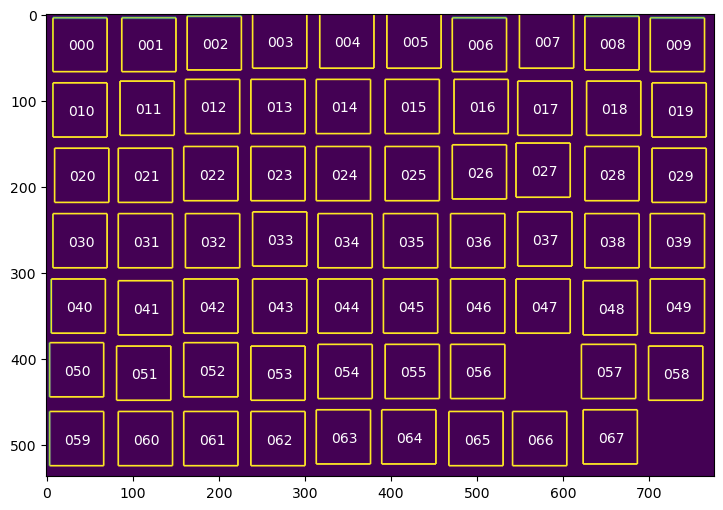

In [ ]:
# plot the box's locations

myscalefactor = 100
mywidth = 100

# create downscaled image of boxes
boxes = np.zeros((image.shape[0],image.shape[1]))
for index, row in tqdm(df_components.iterrows()):
    # add boundaries
    [x,y,w,h] = row['bounding_box']
    boxes[y-mywidth:y+mywidth,x:x+w] = 1
    boxes[y+h-mywidth:y+h+mywidth,x:x+w] = 1
    boxes[y:y+h,x-mywidth:x+mywidth] = 1
    boxes[y:y+h,(x+w-mywidth):(x+w+mywidth)] = 1
    
    # # set the 'box_number', add text to image
    # str_to_insert = f"_box{index:03}"
    # ax.text(y,x,str_to_insert)

boxes_downscaled = downscale_image(boxes,scalefactor=myscalefactor)

_,ax = plt.subplots(figsize=(12,6))
ax.imshow(boxes_downscaled)

for index, row in tqdm(df_components.iterrows()):
    # get box boundaries
    [x,y,w,h] = row['bounding_box']
    
    # set text coordinates
    text_coord_1 = round((x+0.5*w)/myscalefactor)
    text_coord_2 = round((y+0.5*h)/myscalefactor)
    
    # set the 'box_number', add text to image
    str_to_insert = f"{index:03}"
    ax.text(text_coord_1,text_coord_2,str_to_insert,ha='center',va='center',color='white')

del myscalefactor,mywidth,boxes,index,row,x,y,w,h
del ax, text_coord_1,text_coord_2, str_to_insert
del boxes_downscaled

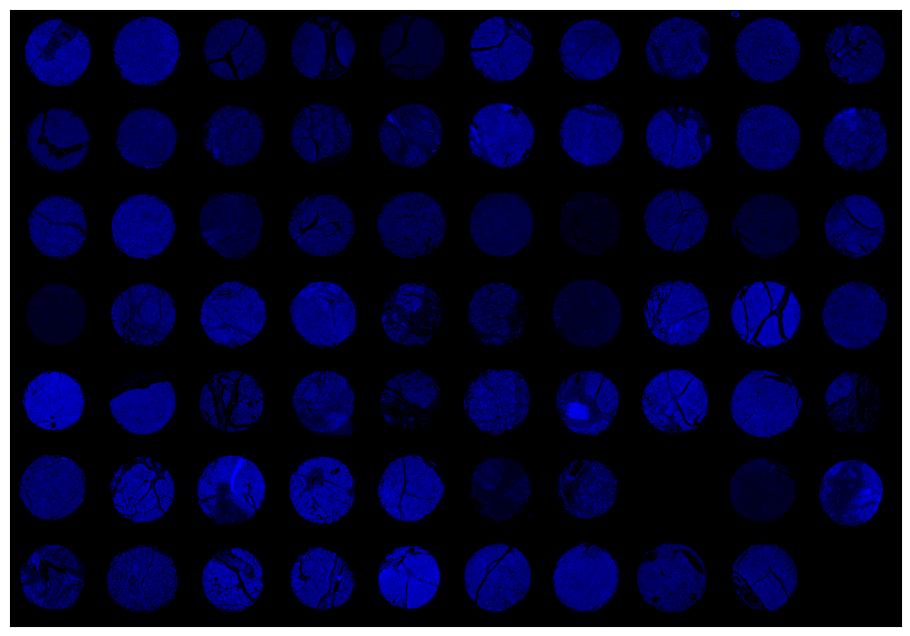

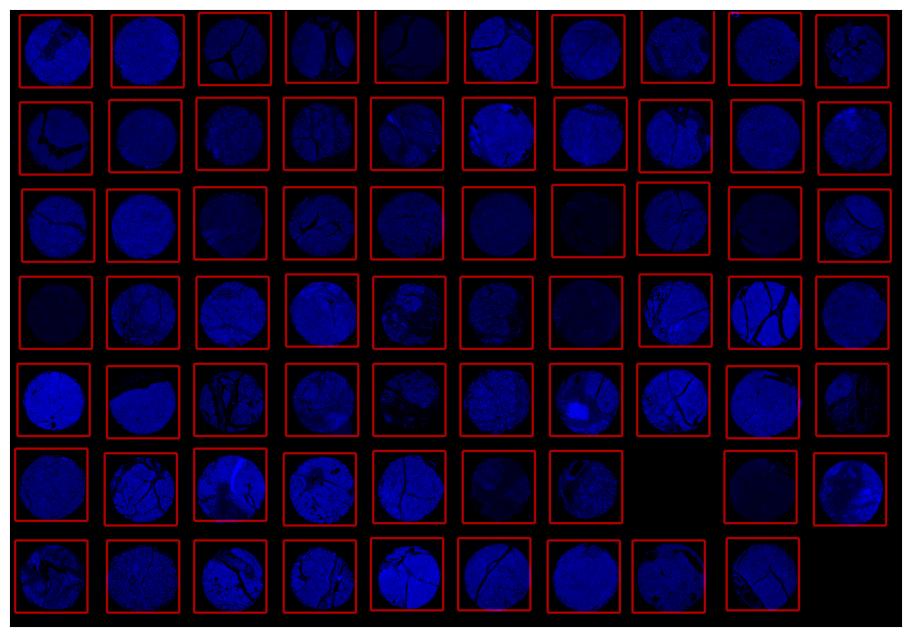

In [ ]:
# plot all bounding boxes, as sanity check 

myscalefactor = 10
mywidth = 100

# create downscaled image of boxes
boxes = np.zeros((image.shape[0],image.shape[1]))
for [x,y,w,h] in df_components['bounding_box']:
    boxes[y-mywidth:y+mywidth,x:x+w] = 1
    boxes[y+h-mywidth:y+h+mywidth,x:x+w] = 1
    boxes[y:y+h,x-mywidth:x+mywidth] = 1
    boxes[y:y+h,(x+w-mywidth):(x+w+mywidth)] = 1
    
boxes_downscaled = downscale_image(boxes,scalefactor=myscalefactor)

del x,y,w,h,boxes,mywidth

# downscale image size
image_downscaled = downscale_image(image,scalefactor=myscalefactor)
image_downscaled = image_downscaled.astype(dtype=np.float32)

# scale image intensity to be between 0 and 1
image_max = np.percentile(image_downscaled,95)
image_min = np.percentile(image_downscaled,5)
image_downscaled -= image_min
image_downscaled /= (image_max - image_min)
image_downscaled[image_downscaled<0] = 0
image_downscaled[image_downscaled>1] = 1

del image_max,image_min
del myscalefactor

# show the original image
image_rgb = np.zeros((boxes_downscaled.shape[0] , boxes_downscaled.shape[1] , 3 ))
image_rgb[:,:,2] = image_downscaled
_,ax0 = plt.subplots(figsize=(12,8))

ax0.imshow(image_rgb)
ax0.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax0.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# compose the downscaled image, and display downscaled boxes image
image_rgb = np.zeros((boxes_downscaled.shape[0] , boxes_downscaled.shape[1] , 3 ))
image_rgb[:,:,0] = boxes_downscaled*0.7
image_rgb[:,:,2] = image_downscaled

_,ax1 = plt.subplots(figsize=(12,8))
ax1.imshow(image_rgb)
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

del ax0,ax1,image_rgb,image_downscaled,boxes_downscaled

In [ ]:
del coordinates, coordinates_downscaled, coordinates_image_downscaled
del counter, diameter, image, mydict, mylist, out_image_downscaled
del radius, radius_downscaled, raw_data_directory, rim, scalefactor

# save regions in bounded boxes as .npy files

In [ ]:
# from previous cells, only requires the dataframe 'df_components'

# set directories, and the dapi file you want to use
raw_data_directory = '../raw_data/' # filesep at end
target_directory =   '../raw_data_modified/cores_npy/'
dapi_special_filename = 'SLIDE-0265_1.0.4_R000_DAPI__FINAL_F.ome.tif'

# get the list of .ome.tiff files
filenames = os.listdir(raw_data_directory)
filenames = [x for x in filenames if x.endswith('.tif')]

# remove all filenames with dapi, then add back just 1 of the dapi images
filenames = [x for x in filenames if 'dapi' not in x.lower()]
filenames.insert(0,dapi_special_filename)
del dapi_special_filename

# filenames = filenames[0:5] # debugging code

for filename in tqdm(filenames,desc='Outer Loop',position=0):
    # load image
    with TiffFile(raw_data_directory + filename) as tif:
        image = tif.asarray()
    del tif
    
    # loop thru rectangles
    for index, row in tqdm(df_components.iterrows(),desc='Inner Loop',leave=False):
        # get the sub image
        [x,y,w,h] = row['bounding_box']
        image_sub = image[y:y+h,x:x+w] 
        
        # set new filename
        str_to_insert = f"_core{index:03}"
        position = filename.find('.ome.tif')
        target_filename = filename[:position] + str_to_insert + '.npy'
        target_filename = target_directory + target_filename
        del str_to_insert,position
        
        # save sub image
        if os.path.exists(target_filename):
            pass # do nothing, the file already exists
        else:
            np.save(target_filename,image_sub)
            # pass # do nothing for now
            
        
        del target_filename
    
    del image

print('Completed Saving Core Image Files')

del filenames, filename, index, row, x,y,w,h
del image_sub


Outer Loop: 100%|██████████| 52/52 [2:31:15<00:00, 174.52s/it]  

Completed Saving Core Image Files


In [ ]:
# save df_components
target_directory =   '../raw_data_modified/cores_npy/'
df_components.to_pickle(target_directory + 'df_components.pkl')


# core image viewer

In [ ]:
core_code_num = -1

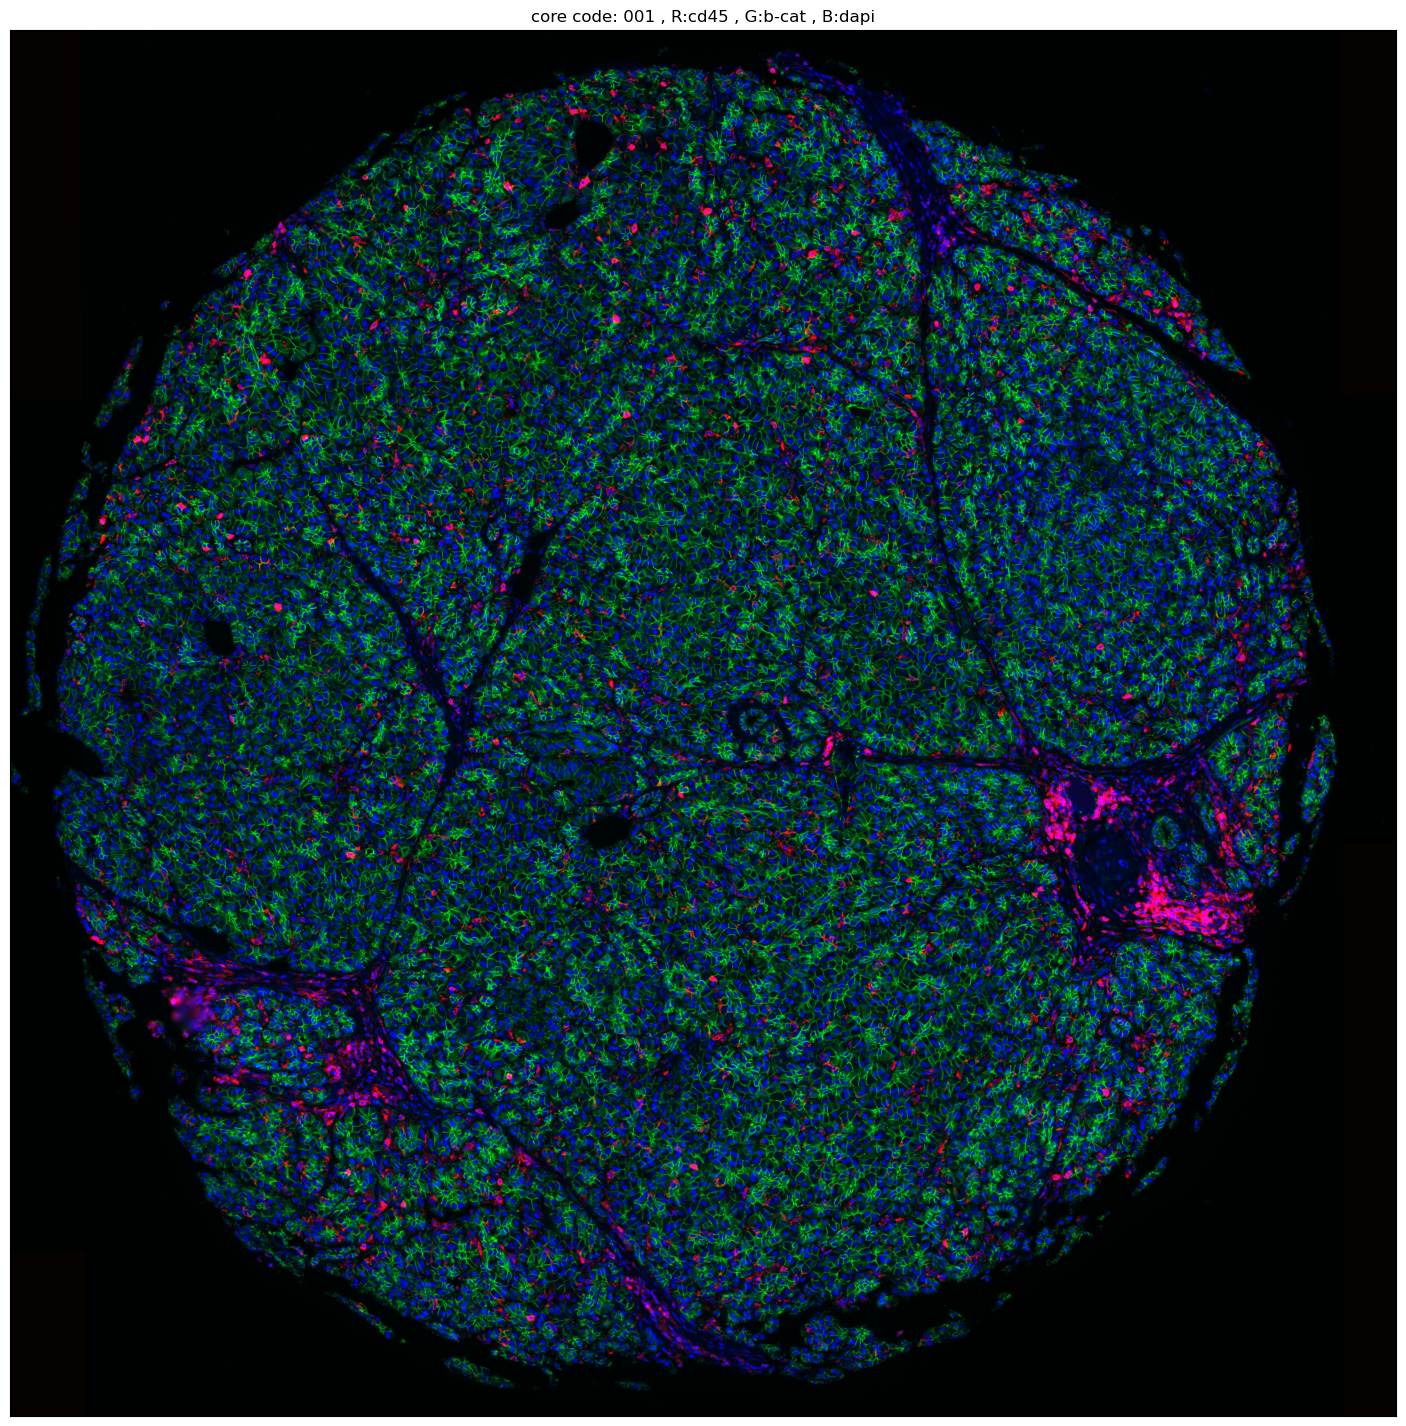

In [ ]:
# box_code_number = 11
core_code_num += 1

core_npy_directory =  '../raw_data_modified/cores_npy/' # filesep at end
markers = ['tnc', 'krt17', 'dapi'] # R G B 
markers = ['cd45', 'b-cat', 'dapi'] # R G B 

filenames = os.listdir(core_npy_directory)
filenames = [x for x in filenames if x.endswith('.npy')]

core_code_str = f"core{core_code_num:03}"

def process_cupy_array(filename):
    # Load the .npy file as a CuPy array
    array = cp.load(filename)

    # Convert to float32
    array = array.astype(cp.float32)

    # Calculate the minimum and maximum values using CuPy
    array_min = array.min()
    array_max = cp.percentile(array, 99.7)

    # Normalize the array to [0, 1]
    array -= array_min
    array /= (array_max - array_min)

    # Clip the values to stay within [0, 1]
    cp.clip(array, 0, 1, out=array)

    # Return as a NumPy array (moving the data from GPU to CPU)
    return array

for channel,marker in enumerate(markers):
    filename = [x for x in filenames if core_code_str in x.lower() and marker in x.lower()]
    if len(filename)>1:
        print('uh oh did not find exactly one file')
        print(filename)
        filename = [filename[1]] # careful!
    
    filename = filename[0] # careful here
    array = process_cupy_array(core_npy_directory+filename)
    
    # array = np.load(target_directory + filename)
    # array = array.astype(np.float32)
    # array_min = array.min() #np.percentile(array,10)
    # array_max = np.percentile(array,99.5)
    # array -= array_min
    # array /= (array_max - array_min)
    # np.clip(array, 0, 1, out=array)
    
    if channel==0: array_rgb_cp = cp.zeros((array.shape[0],array.shape[1],3)); 
    array_rgb_cp[:,:,channel] = array

del core_npy_directory,filenames,core_code_str
del channel, filename,array    
show_red = 1
show_green = 1
show_blue = 1

myimg_mayfly_cp = array_rgb_cp.copy()
if show_red==0: myimg_mayfly_cp[:,:,0] = 0*myimg_mayfly_cp[:,:,0]; 
if show_green==0: myimg_mayfly_cp[:,:,1] = 0*myimg_mayfly_cp[:,:,1]; 
if show_blue==0: myimg_mayfly_cp[:,:,2] = 0*myimg_mayfly_cp[:,:,2]; 

myimg_mayfly = myimg_mayfly_cp.get()

_,ax = plt.subplots(figsize=(18,18))
ax.imshow(myimg_mayfly)
ax.set_title(f"core code: {core_code_num:03} , R:{markers[0]} , G:{markers[1]} , B:{markers[2]}")
ax.set_xticklabels([]); ax.set_yticklabels([])
ax.set_xticks([]); ax.set_yticks([])

del show_red,show_green,show_blue,ax

# OLD CODE

## test image

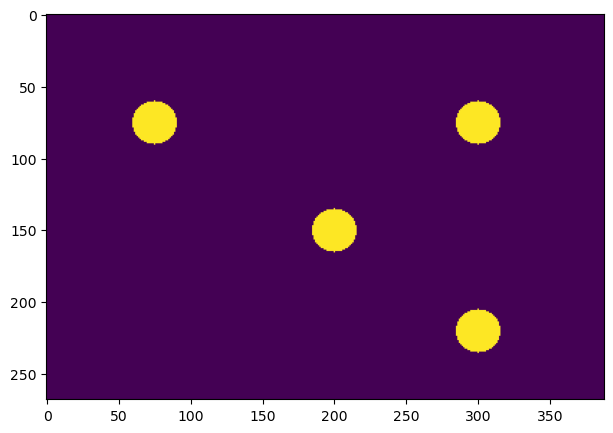

In [ ]:
test_image = np.zeros_like(image_downscaled)

test_image[75,75] = 1
test_image[150,200] = 1
test_image[220,300] = 1
test_image[75,300] = 1

radius = 15
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*radius+1, 2*radius+1))

test_image = cv2.dilate(test_image, kernel, iterations=1)

_,ax = plt.subplots(figsize = (10,5))
ax.imshow(test_image)

del ax, radius

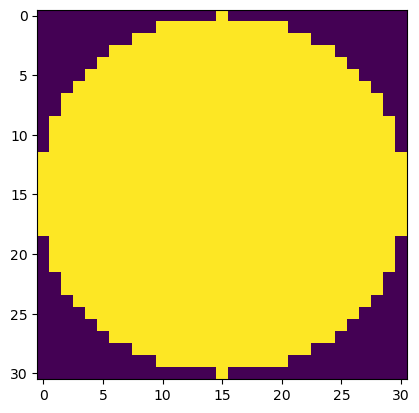

In [ ]:
plt.imshow(kernel)

In [ ]:
from cupyx.scipy.signal import fftconvolve
from skimage.morphology import disk

radius = 15

I_gpu = cp.asarray(test_image, dtype=cp.float32)
K = disk(radius).astype(np.float32)
K /= K.sum()
K_gpu = cp.asarray(K)

out_gpu = fftconvolve(I_gpu, K_gpu, mode='same')
out_test_image = cp.asnumpy(out_gpu)  # if you need it back on CPU


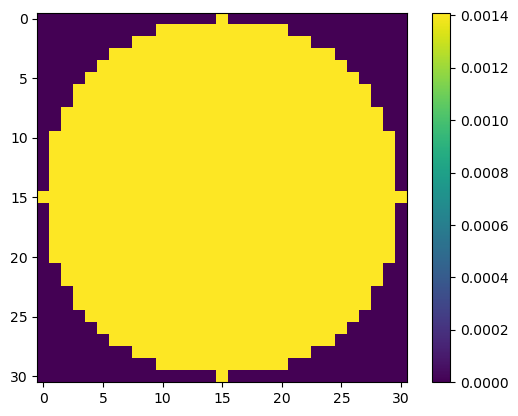

In [ ]:
plt.imshow(K)
plt.colorbar()

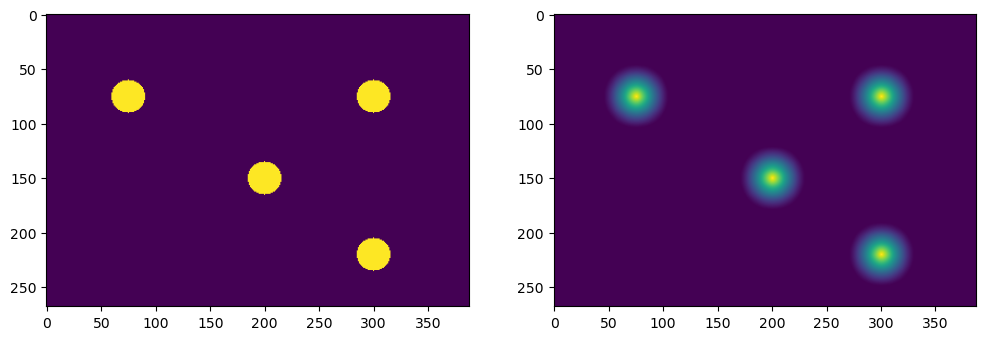

In [ ]:
_,ax_grid = plt.subplots(1,2,figsize=(12,6))
ax = ax_grid[0];  ax.imshow(test_image)
ax = ax_grid[1];  ax.imshow(out_test_image)

del ax_grid, ax

### finding peaks

(4, 2)


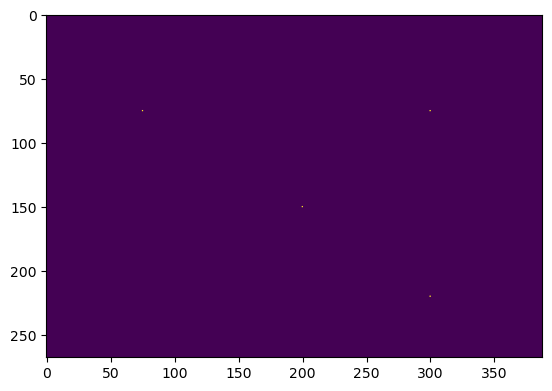

In [ ]:
from skimage.feature import peak_local_max

# I: 2D image, float32 or uint16
coordinates = peak_local_max(
    out_test_image,
    min_distance=10,      # minimum pixels between peaks
    threshold_abs=0.2,    # intensity threshold
    exclude_border=True   # ignore edges
)

coordinates_image = np.zeros_like(test_image)
for item in coordinates:
    coordinates_image[item[0],item[1]] = 1
del item

print(coordinates.shape)  # (N_peaks, 2)
plt.imshow(coordinates_image)


In [ ]:
from cupyx.scipy.ndimage import maximum_filter

I_gpu = cp.asarray(out_test_image, dtype=cp.float32)
maxf = maximum_filter(I_gpu, size=15)
mask = I_gpu == maxf
coords = cp.argwhere(mask).get()


In [ ]:
type(maxf)

In [ ]:
coords.shape

(99728, 2)